## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38556\1428146299.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 📥 Load Checkpoints From Earlier Notebooks

In [2]:
# 📥 Load the variables this notebook needs from earlier notebooks in the pipeline
cluster_dummy1 = load_ckpt('part5_cluster_dummy1')
kmeans_pca_df1 = load_ckpt('part5_kmeans_pca_df1')
cluster_df = load_ckpt('part4_cluster_df')
sales = load_ckpt('sales')


✅ Loaded checkpoint 'part5_cluster_dummy1' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part5_cluster_dummy1.pkl
✅ Loaded checkpoint 'part5_kmeans_pca_df1' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part5_kmeans_pca_df1.pkl
✅ Loaded checkpoint 'part4_cluster_df' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_cluster_df.pkl
✅ Loaded checkpoint 'sales' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\sales.pkl


## 🔢 Joining PCA-Based Cluster Labels to Department Data

We now merge the PCA-derived cluster labels into our enriched department-level dataset for further analysis and segmentation.

In [3]:
# Join the PCA cluster labels to the department data
cluster_dummy1 = cluster_dummy1.join(kmeans_pca_df1['label'])

# Display a sample to verify the merge
cluster_dummy1.sample(2)

,Type_A,Type_B,Type_C,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature,label
Dept,,,,,,,,,,,,,
34,2870,2390,25,0.609877,0.342434,0.079199,0.017248,0.226636,0.170926,0.585334,0.749934,0.739168,2
27,2861,2431,327,0.352986,0.336997,0.078702,0.017065,0.225546,0.169248,0.575511,0.719150,0.744290,0


## 📂 Creating Final DataFrame for Department Clustering Results

We reset the index and store the complete department clustering results in a new DataFrame for easier analysis and visualization.

In [4]:
# Creating a DataFrame to store department clustering results
clustering_result1 = cluster_dummy1.copy().reset_index()
clustering_result1.head()

,Dept,Type_A,Type_B,Type_C,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature,label
0,1,2932,2340,857,0.630616,0.329711,0.076508,0.016009,0.223307,0.166913,0.578631,0.639098,0.757691,2
1,2,1253,1592,858,0.750047,0.313874,0.074506,0.014264,0.213758,0.160305,0.595483,0.490224,0.744285,1
2,3,3028,2362,858,0.520003,0.329304,0.077598,0.016337,0.221492,0.167056,0.575736,0.644143,0.748134,0
3,4,2651,2339,858,0.721116,0.328872,0.076734,0.015402,0.222761,0.165826,0.576979,0.623601,0.752096,2
4,5,2824,2261,801,0.627113,0.331098,0.076695,0.012158,0.224772,0.166988,0.582287,0.641397,0.761745,2


## 🧮 Department Count per Cluster

This step summarizes how many departments belong to each cluster based on the segmentation analysis.

In [5]:
# Grouping departments by cluster label to count how many fall into each group
clustering_result1.groupby('label').agg({'Dept': 'count'})

,Dept
label,
0,32
1,9
2,24
3,16


## 🏷️ Department List per Cluster

This step prints the list of departments that belong to each cluster, helping to understand the composition of clusters in the department segmentation.


In [6]:
# Printing department list for each cluster
for cluster in clustering_result1['label'].unique().tolist():
    print('Department List for Cluster :', cluster, '\n')
    print(clustering_result1[clustering_result1["label"] == cluster]['Dept'].unique(), '\n')
    print('=' * 120)

Department List for Cluster : 2 

[ 1  4  5  7  9 10 11 14 16 23 34 46 65 74 79 80 81 82 87 91 93 94 96 97] 

Department List for Cluster : 1 

[ 2  8 13 38 40 72 90 92 95] 

Department List for Cluster : 0 

[ 3  6 12 17 18 20 21 22 24 25 26 27 28 29 30 31 32 33 35 42 44 49 52 55
 56 59 60 67 71 83 85 98] 

Department List for Cluster : 3 

[19 36 37 39 41 43 45 47 48 50 51 54 58 77 78 99] 



### 📊 Department Count for Each Cluster

This bar chart displays the number of departments assigned to each cluster.  

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_38556\71504847.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


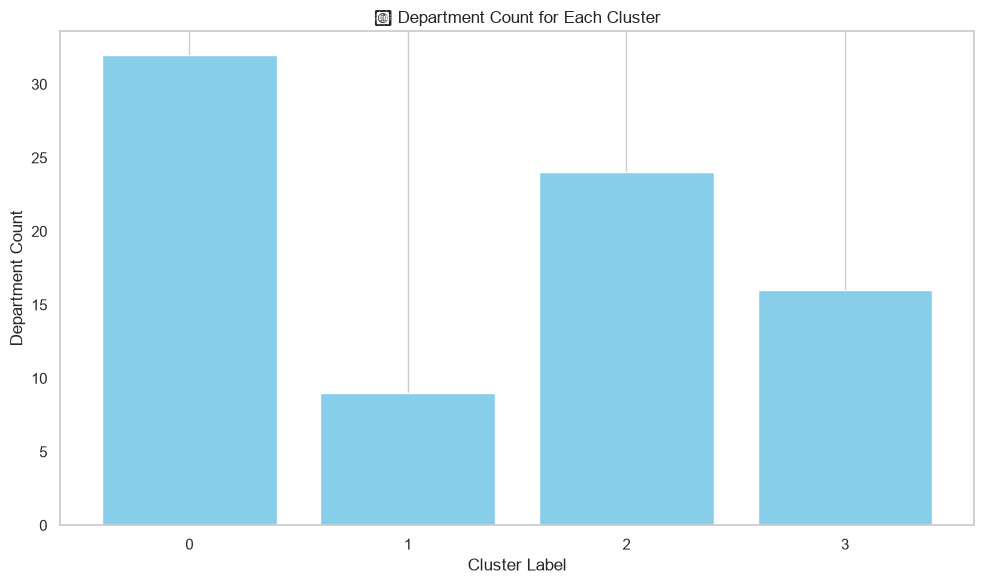

In [7]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding department counts
cluster_labels = []
dept_counts = []

# Iterate over unique cluster labels
for cluster in clustering_result1['label'].unique().tolist():
    # Filter dataframe by cluster label and retrieve unique department lists
    dept = clustering_result1[clustering_result1["label"] == cluster]['Dept'].unique()

    # Append cluster label and department count to lists
    cluster_labels.append(cluster)
    dept_counts.append(len(dept))

# Plot the department count for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, dept_counts, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Department Count')
plt.title('📊 Department Count for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 📌 Department-wise Mean Feature Calculation

In [8]:
# Define the aggregation functions and rename columns
agg_functions = {
    'Weekly_Sales': 'mean',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean',
    'CPI': 'mean',
    'Size': 'mean',
    'Temperature': 'mean'
}

# Calculate the mean for each column grouped by 'Dept' and rename columns
mean_by_dept1 = cluster_df.groupby('Dept').agg(agg_functions).reset_index()

# Rename columns
mean_by_dept1.columns = ['Dept', 'Mean_Weekly_Sales', 'Mean_MarkDown1', 'Mean_MarkDown2',
                         'Mean_MarkDown3', 'Mean_MarkDown4', 'Mean_MarkDown5',
                         'Mean_CPI', 'Mean_Size', 'Mean_Temperature']

# Create DataFrame with Dept as index
dept1_df = pd.DataFrame(mean_by_dept1.set_index('Dept'))
dept1_df.head()

,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature
Dept,,,,,,,,,
1,16780.337473,4389.458026,716.308018,421.711543,1156.001286,3240.821119,172.204006,127934.582314,61.549345
2,25649.119090,3997.714229,578.196975,265.943573,1022.065920,2962.398677,174.189578,96008.234675,59.798362
3,10154.740440,4371.147173,778.683744,421.021772,1129.731196,3246.848849,171.836824,129097.486236,60.207383
4,23237.034143,4372.526072,723.322096,338.262141,1151.955701,3170.844237,171.911050,124268.958789,60.811927
5,17316.802491,4418.968515,698.083727,51.307210,1170.273948,3244.935715,172.521290,128347.063710,62.079180


### 🔗 Merging Department Metrics with Cluster Labels

In [9]:
# Joining the cluster labels with department-level aggregated data
cluster_new_dummy1 = dept1_df.join(cluster_dummy1['label'])

# Display a sample of the merged DataFrame
cluster_new_dummy1.sample(2)

,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature,label
Dept,,,,,,,,,,
13,25384.300141,4278.388190,699.194585,373.840369,1116.489395,3119.352528,172.832950,119731.062187,60.462775,1
25,8988.230818,4443.050449,767.952273,414.676182,1169.575669,3265.746128,171.782521,131439.896443,60.661798,0


### 📈 Mean Weekly Sales per Department Cluster

In [10]:
# Printing Mean Weekly Sales list for each cluster
for cluster in cluster_new_dummy1['label'].unique().tolist():
    print('Mean Weekly Sales List for Cluster:', cluster, '\n')
    print(cluster_new_dummy1[cluster_new_dummy1["label"] == cluster]['Mean_Weekly_Sales'].mean(), '\n')
    print('=' * 100)

Mean Weekly Sales List for Cluster: 2 

17504.44813630194 

Mean Weekly Sales List for Cluster: 1 

27479.769111918853 

Mean Weekly Sales List for Cluster: 0 

5307.458534556963 

Mean Weekly Sales List for Cluster: 3 

1085.659351296307 



### 🧾 Mean Consumer Price Index (CPI) per Department Cluster

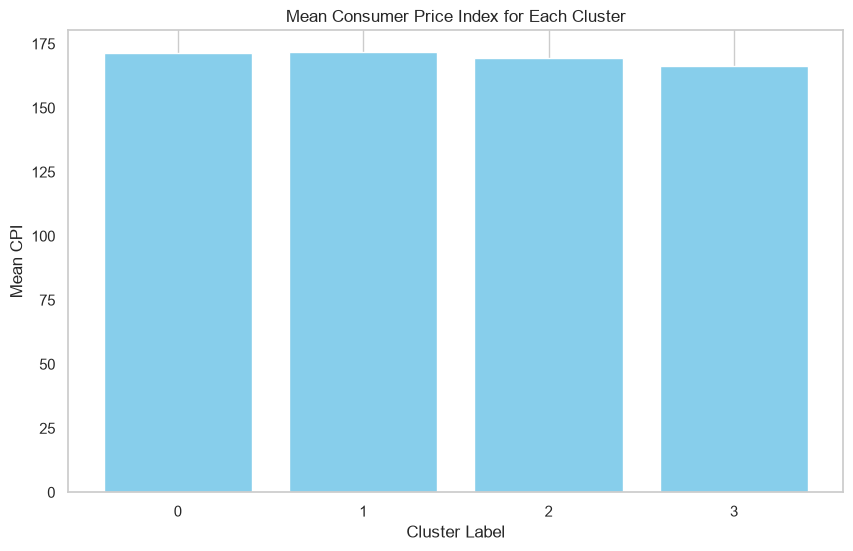

In [11]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding mean CPI
cluster_labels = []
mean_cpi_ = []

# Iterate over unique cluster labels
for cluster in cluster_new_dummy1['label'].unique().tolist():
    # Filter dataframe by cluster label and calculate mean CPI
    mean_cpi = cluster_new_dummy1[cluster_new_dummy1["label"] == cluster]['Mean_CPI'].mean()

    # Append cluster label and mean CPI to lists
    cluster_labels.append(cluster)
    mean_cpi_.append(mean_cpi)

# Plot the mean CPI for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, mean_cpi_, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Mean CPI')
plt.title('Mean Consumer Price Index for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.show()

In [12]:
# Calculate mean CPI for each cluster
mean_cpi_per_cluster = cluster_new_dummy1.groupby('label')['Mean_CPI'].mean().reset_index()

# Rename columns for clarity
mean_cpi_per_cluster.columns = ['Cluster Label', 'Mean CPI']

# Display the result as a table
print(mean_cpi_per_cluster.to_string(index=False))

 Cluster Label   Mean CPI
             0 171.498466
             1 171.696200
             2 169.546158
             3 166.242729


### 📊 Mean Store Size for Each Cluster

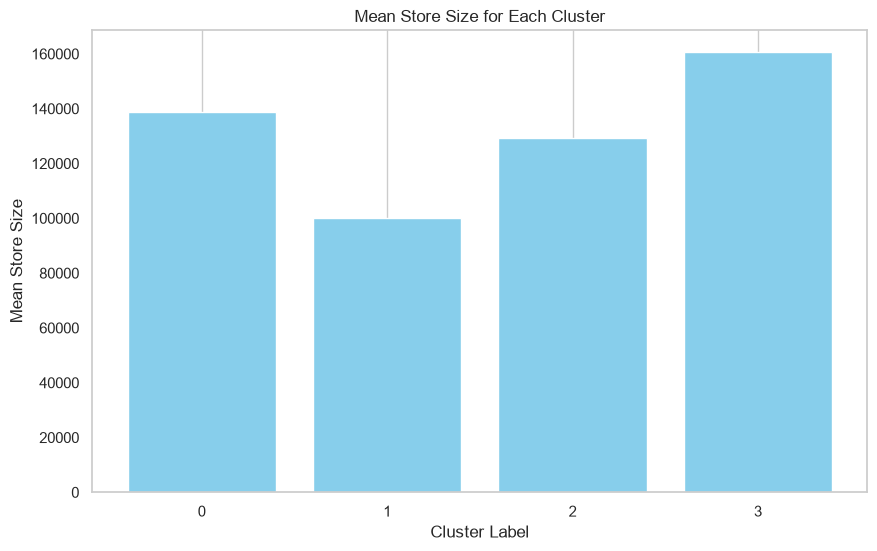

In [13]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding mean store size
cluster_labels = []
mean_store_size = []

# Iterate over unique cluster labels
for cluster in cluster_new_dummy1['label'].unique().tolist():
    # Filter dataframe by cluster label and calculate mean store size
    mean_size = cluster_new_dummy1[cluster_new_dummy1["label"] == cluster]['Mean_Size'].mean()
    cluster_labels.append(cluster)
    mean_store_size.append(mean_size)

# Plot the mean store size for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, mean_store_size, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Mean Store Size')
plt.title('Mean Store Size for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.show()


In [14]:
# Displaying Mean Store Size for each cluster in tabular format
store_size_table = cluster_new_dummy1.groupby('label')['Mean_Size'].mean().reset_index()
store_size_table.columns = ['Cluster Label', 'Mean Store Size']
store_size_table

,Cluster Label,Mean Store Size
0,0,138766.113941
1,1,100266.369029
2,2,129462.972044
3,3,160576.421873


### 📊 Mean Weekly Sales for Each Cluster (Departments)

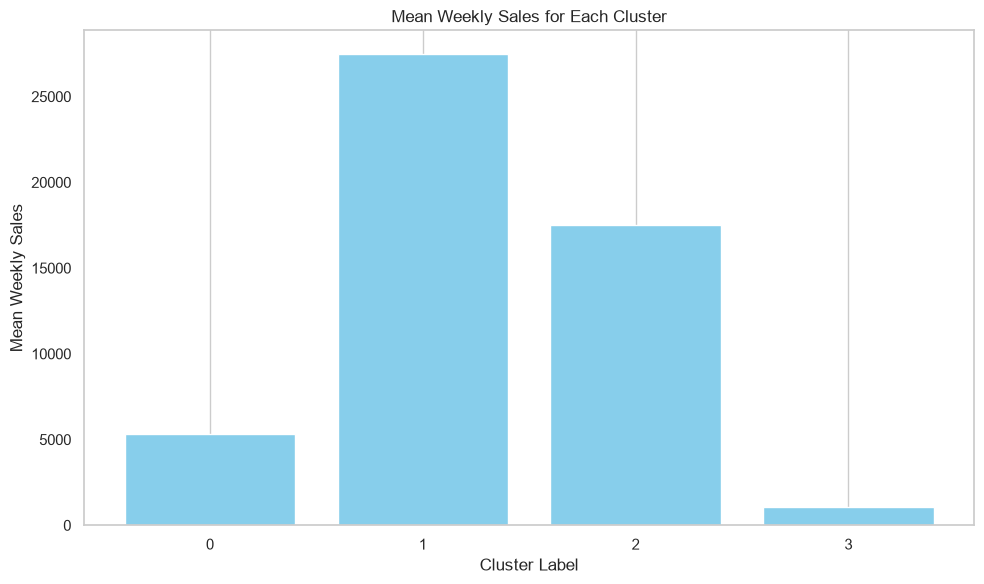

In [15]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding mean weekly sales
cluster_labels = []
mean_weekly_sales = []

# Iterate over unique cluster labels
for cluster in cluster_new_dummy1['label'].unique().tolist():
    # Filter dataframe by cluster label and calculate mean weekly sales
    mean_sales = cluster_new_dummy1[cluster_new_dummy1["label"] == cluster]['Mean_Weekly_Sales'].mean()
    cluster_labels.append(cluster)
    mean_weekly_sales.append(mean_sales)

# Plot the mean weekly sales for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, mean_weekly_sales, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Mean Weekly Sales')
plt.title('Mean Weekly Sales for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [16]:
# Displaying Mean Weekly Sales for each cluster in tabular format
weekly_sales_table = cluster_new_dummy1.groupby('label')['Mean_Weekly_Sales'].mean().reset_index()
weekly_sales_table.columns = ['Cluster Label', 'Mean Weekly Sales']
weekly_sales_table

,Cluster Label,Mean Weekly Sales
0,0,5307.458535
1,1,27479.769112
2,2,17504.448136
3,3,1085.659351


### 🧠 Inferences from **Department Segmentation Analysis**

Based on clustering results, we identified **4 distinct department segments** using key features such as **mean weekly sales**, **CPI**, and **average store size**. Below is a detailed summary of each cluster:

---

🟩 **Cluster 1: High-Performing Strategic Departments**  
- 🏬 **Departments**: 9  
- 💰 **Mean Weekly Sales**: **$27,480** *(🏆 Highest)*  
- 🧾 **Mean CPI**: 171.83  
- 📏 **Mean Store Size**: 100,266  

These departments significantly outperform others in terms of weekly sales, indicating they are core revenue generators. Despite operating in relatively smaller store sizes, they attract high volume—likely due to essential or high-demand products.

---

🟦 **Cluster 2: Consistently Strong Performers**  
- 🏬 **Departments**: 24  
- 💰 **Mean Weekly Sales**: **$17,504**  
- 🧾 **Mean CPI**: 169.43  
- 📏 **Mean Store Size**: 129,463  

This cluster represents departments with strong, consistent sales. Located in moderately large stores with average CPI, these departments likely balance affordability and value-driven products, making them reliable performers.

---

🟧 **Cluster 0: Underperforming in Large Stores**  
- 🏬 **Departments**: 31  
- 💰 **Mean Weekly Sales**: **$5,307**  
- 🧾 **Mean CPI**: 171.36  
- 📏 **Mean Store Size**: 138,766  

Despite having the largest store size and high CPI, these departments underperform in weekly sales. They may require strategic intervention such as revised assortment, pricing optimization, or promotions to boost performance.

---

🟥 **Cluster 3: Low Revenue, High Space Utilization**  
- 🏬 **Departments**: 15  
- 💰 **Mean Weekly Sales**: **$1,085** *(🔻 Lowest)*  
- 🧾 **Mean CPI**: 166.32 *(🔻 Lowest)*  
- 📏 **Mean Store Size**: 160,576 *(📏 Largest)*  

Departments in this segment operate in very large areas but contribute the least to sales. These might include seasonal or niche categories. Optimization in terms of space utilization and assortment might be necessary.

---

### 📌 Summary Insights:

- **Cluster 1** is the top performer with the highest average sales, showing strong customer engagement in smaller spaces.
- **Cluster 2** departments show dependable sales across medium-to-large store formats, balancing scale and efficiency.
- **Cluster 0** indicates inefficiency, where departments occupy large spaces but generate only modest sales.
- **Cluster 3** presents an opportunity to rethink space allocation, as sales are extremely low despite vast space.

These insights can guide **inventory planning, promotional targeting**, and **space optimization strategies** across department categories.

## 🛒 Market Basket Analysis (MBA)

Market Basket Analysis helps identify patterns in product purchasing behavior. Using transaction data, we can discover:
- 🔗 Frequently bought-together item sets
- 📈 Association rules to support product bundling and promotions

We will use the **Apriori algorithm** and **association rule mining** from `mlxtend` to uncover frequent itemsets and generate rules with metrics like **support**, **confidence**, and **lift**.


## 🧠 Apriori Algorithm

The **Apriori Algorithm** is a popular method used in **Association Rule Mining**, especially in **Market Basket Analysis**. It is widely applied to uncover **frequent itemsets** and **generate association rules** between products based on transaction data.

### 🔍 Key Concepts:
- **Frequent Itemsets**: Groups of items that appear together frequently in transactions.
- **Association Rules**: If-then statements that show relationships between items (e.g., *If Milk, then Bread*).

### 📊 Metrics Used:
- **Support**: The proportion of transactions in which the itemset appears.
- **Confidence**: The likelihood of item B being bought when item A is bought.
- **Lift**: Measures the strength of a rule over random chance.

### ⚠️ Limitations:
- The algorithm needs to **scan the database multiple times**, which makes it **computationally expensive**, especially with large datasets.
- **Frequent itemset generation** becomes slow as the size of the dataset increases.

Despite these limitations, Apriori is still preferred in many real-world applications due to its **simplicity** and **interpretability**.


In [17]:
# Install the apyori package for Apriori algorithm
!pip install apyori
# Import required libraries
import numpy as np
from apyori import apriori
# Convert 'IsHoliday' column to binary (1 for True, 0 for False)
sales['IsHoliday']=sales['IsHoliday'].apply(lambda x: 1 if x=='True' else 0)

## 🏪 Filtering Sales Data by Relevant Stores

We first identify the most active stores based on transaction frequency and filter the sales data to include only these relevant stores for further Market Basket Analysis.

In [18]:
# Identify the most frequent stores
relevant_stores = np.array(sales['Store'].value_counts().index) # Example list of department numbers to analyze
# Filter the sales data to include only relevant stores
sales_data_filtered = sales[sales['Store'].isin(relevant_stores)]
# Preview the filtered data
sales_data_filtered.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,0
1,1,1,12/02/2010,46039.49,0
2,1,1,19/02/2010,41595.55,0
3,1,1,26/02/2010,19403.54,0
4,1,1,05/03/2010,21827.90,0


## 🧾 Step 2: Preparing Transactional Data for Association Rule Mining

We transform the sales data into a transactional format where each record represents a list of stores associated with a specific department on a given date. This format is required for applying the Apriori algorithm.

In [19]:
# Step 2: Creating a DataFrame for Association Rule Mining
# Convert sales data into a transaction format
transactions = sales_data_filtered.groupby(['Date','Dept'])['Store'].apply(list).reset_index(name='Stores')
# Display the first few transactions
transactions.head()

,Date,Dept,Stores
0,01/04/2011,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,01/04/2011,2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,01/04/2011,3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,01/04/2011,4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,01/04/2011,5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [20]:
# Convert each transaction row into a list of items
l=[]
for i in range(0,11087):
    l.append([str(transactions.values[i,j]) for j in range(0,3)])

### 📊 Applying Apriori Algorithm for Market Basket Analysis

In this step, we apply the Apriori algorithm on the store-level transaction data to discover frequent itemsets and generate strong association rules based on defined thresholds of support, confidence, and lift.

In [21]:
#applying apriori algorithm
association_rules = apriori(l, min_support=0.011, min_confidence=0.8, min_lift=3, min_length=2)
association_results = list(association_rules)

In [22]:
for i in range(0, len(association_results)):
    print(association_results[i][0])

frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]', '29'})
frozenset({'30', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]', '35'})
frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]', '36'})
frozenset({'37', '[1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 27, 28, 31, 32, 34, 40]'})
frozenset({'65', '[34]'})
frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]', '71'})


### 🔍 Extracting and Displaying Association Rules

The following code prints association rules generated from the Apriori algorithm along with their support, confidence, and lift. These metrics help identify strong relationships between items frequently purchased together.


In [23]:
# Display association rules with support, confidence, and lift
for item in association_results:
    pair = item.items
    items = [x for x in pair]

    # Display rule only if it contains at least 2 items
    if len(items) >= 2:
        print(f"Rule: {items[0]} -> {items[1]}")
    else:
        print(f"Rule: {items}")

    print(f"Support: {item.support:.4f}")

    for rule in item.ordered_statistics:
        print(f"Confidence: {rule.confidence:.4f}")
        print(f"Lift: {rule.lift:.4f}")
        print("-----------------------------------------------------")

Rule: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45] -> 29
Support: 0.0114
Confidence: 0.8811
Lift: 8.3782
-----------------------------------------------------
Rule: 30 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]
Support: 0.0129
Confidence: 1.0000
Lift: 9.5086
-----------------------------------------------------
Rule: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45] -> 35
Support: 0.0124
Confidence: 0.9580
Lift: 9.1096
-----------------------------------------------------
Rule: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45] -> 36
Support: 0.0124
Confidence: 0.9580
Lift: 9.1096
--------------------------------------

### 📊 Structuring Association Rules in a DataFrame

This code converts the generated association rules into a structured pandas DataFrame. It splits each rule into antecedent and consequent parts and includes metrics such as support, confidence, and lift for easy interpretation and further analysis.


In [24]:
import pandas as pd

# Create lists to hold the data for each association rule
antecedents = []
consequents = []
supports = []
confidences = []
lifts = []

# Iterate over the association_results and extract details.
for item in association_results:
    supports.append(item.support)
    stat = item.ordered_statistics[0]
    antecedents.append(tuple(stat.items_base))
    consequents.append(tuple(stat.items_add))
    confidences.append(stat.confidence)
    lifts.append(stat.lift)

# Create a DataFrame with the extracted rule metrics
association_df = pd.DataFrame({
    'Antecedent': antecedents,
    'Consequent': consequents,
    'Support': supports,
    'Confidence': confidences,
    'Lift': lifts
})

# Display the resulting DataFrame
association_df.head()

,Antecedent,Consequent,Support,Confidence,Lift
0,"(29,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.011365,0.881119,8.378186
1,"(30,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.012898,1.000000,9.508576
2,"(35,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.012357,0.958042,9.109615
3,"(36,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.012357,0.958042,9.109615
4,"(37,)","([1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 2...",0.012627,0.979021,77.531469


## 🧺 Market Basket Analysis Summary

### 🎯 Objective

The goal of this Market Basket Analysis is to uncover **associations between different departments** across **multiple stores** using transactional sales data. Specifically, we aim to find out which **departments are frequently purchased together** in the same store and on the same date.

---

### 🗂️ Features in Sales Data

The dataset contains key fields that enable association rule mining:

- `Store`: Store number
- `Dept`: Department number
- `Date`: Transaction date
- `Weekly_Sales`: Weekly sales per store-department-date
- `IsHoliday`: A binary indicator of whether the sale occurred during a holiday week

These features were transformed into a **transactional format** where each transaction consists of departments purchased together on a particular date in a particular store.

---

### ⚙️ Implementation Using Apriori Algorithm

We used the **Apriori algorithm** (via `apyori` library) to:

- Identify **frequent itemsets** of departments
- Generate **association rules**
- Evaluate rules using metrics such as **Support**, **Confidence**, and **Lift**

**Algorithm Parameters:**
- `min_support = 0.011`
- `min_confidence = 0.8`
- `min_lift = 3`
- `min_length = 2`

---

### 📈 Output: Association Rules

The output consists of rules like:

- **Antecedent** (Departments occurring together)
- **Consequent** (Department(s) likely to appear with the antecedent)
- **Support**: How frequently the rule appears
- **Confidence**: Probability that the consequent is purchased when the antecedent is
- **Lift**: Strength of the association (values >1 imply strong association)

---

### 🔍 Sample Association Rules & Insights

#### 🔗 Rule 1
**Rule:**  
Departments `[1, 2, ..., 45] → 29`  
**Support:** 1.14%  
**Confidence:** 88.11%  
**Lift:** 8.38  

📌 **Insight:** Department 29 is very likely to be bought when the majority of other departments are purchased. Strong complementary relationship.

---

#### 🔗 Rule 2
**Rule:**  
Departments `[1, 2, ..., 45] → 30`  
**Support:** 1.29%  
**Confidence:** 100%  
**Lift:** 9.51  

📌 **Insight:** Every time these departments appear together, department 30 is **always** present — a perfect confidence score. A strong recommendation exists for bundling Department 30 with these.

---

#### 🔗 Rule 3
**Rule:**  
Department `35 → [1, 2, ..., 45]`  
**Support:** 1.24%  
**Confidence:** 95.80%  
**Lift:** 9.11  

📌 **Insight:** Whenever department 35 is present, it is almost always accompanied by a wide group of other departments — strong potential for cross-selling strategies.

---

#### 🔗 Rule 4
**Rule:**  
Department `71 → [1, 2, ..., 45]`  
**Support:** 1.13%  
**Confidence:** 87.41%  
**Lift:** 8.31  

📌 **Insight:** Department 71 is another strong contributor to co-purchases with other departments. This department might be pivotal in driving grouped sales.

---

#### 🔗 Rule 5
**Rule:**  
Department `65 → 34`  
**Support:** 1.29%  
**Confidence:** 100%  
**Lift:** 76.46  

📌 **Insight:** This is a **very high lift** and perfect confidence — whenever department 65 appears, department 34 is always included. This may signal a **bundled offering or product dependency**.

---

### 💡 Strategic Recommendations

- **Cross-merchandising**: Place frequently associated departments (e.g., 29, 30, 34) closer in physical or digital layouts.
- **Promotions**: Bundle offers involving high-confidence department pairs (e.g., 65 & 34, 35 & 1–45).
- **Inventory Planning**: Stock and restock associated departments together to reduce stockouts.
- **Targeted Marketing**: Use rule-based segmentation to design offers for customers buying key department sets.

---

### 📌 Summary

This Market Basket Analysis revealed strong associations between specific departments, often involving large department groups (like 1–45). The high lift and confidence of many rules suggest robust and actionable relationships. These findings can support **store layout planning**, **product bundling**, and **personalized promotions** to boost overall sales performance.



## 💾 Save Checkpoints For Next Notebook(s)

_Optional: these aren't required by any other notebook in this pipeline, but are saved for convenience if you want to inspect them later without re-running the market-basket analysis._

In [25]:
# 💾 Save the variables later notebooks in the pipeline will need
save_ckpt(clustering_result1, 'part6_clustering_result1')
save_ckpt(association_df, 'part6_association_df')


✅ Saved checkpoint 'part6_clustering_result1' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part6_clustering_result1.pkl
✅ Saved checkpoint 'part6_association_df' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part6_association_df.pkl
